# Demo of DISC tomography based on checkboard model 

## Description
This notebook implements DISC based on checkboard model.  
It is designed for generating synthetic data, performing ray path matrix reconstruction, and updating velocity models through gradient-based optimization.


## Date
2026-07

In [1]:
#####Step1 import necessary package

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import lsqr
import sys
from pyekfmm import eikonal,ray2d2  #extract traveltime and ray tracing (new) functions from pyekfmm
from pyseistr.solvers import solver,conjgrad
from pyseistr.solvers import cgstep
from pyseistr.operators import adjnull,matrix_lop
from pyseistr.divne import trianglen_lop
from scipy.ndimage import gaussian_filter
import os

In [2]:
#####Step2 create real checkboard model

nx, ny = 50, 50  ###model size 
dx = dy =1       ###spacing rinterval
shape = (50, 50)
tile = (5, 5)  # (tile_height, tile_width); change as needed
v_low = 2000     ###low velocity
v_high = 5000    ###high velocity
iy, ix = np.indices(shape)
checker = ((iy // tile[0]) + (ix // tile[1])) % 2
v_true = np.where(checker == 0, v_low, v_high).astype(np.float32)

#########geometry setting
n_sources = 50 ####number of sources
sources = [(10, (i*(ny-1)*dx/(n_sources-1))) for i in range(n_sources)] #### source locations (x,y)
n_receivers = 50  ####number of recevivers
receivers = [((nx-10)*dx, (i*(ny-1)*dy/(n_receivers-1))) for i in range(n_receivers)] ### receiver locations (x,y)

In [3]:
#####Step3 build ray path matrix based on eikonal wave equation
sources_x=[ii[0] for ii in sources] ########x coordinates of sources
sources_y=[ii[1] for ii in sources] ########y coordinates of sources

receivers_x=[ii[0] for ii in receivers] ########x coordinates of receivers
receivers_y=[ii[1] for ii in receivers] ########y coordinates of receivers

address=os.path.dirname(os.getcwd())
sys.path.insert(0, address)

from disc.raytrace import * ####import necessary functions for traveltime and ray path calculation  

###compute traveltime for each ray based on eikonal equation
traveltimes,ray_paths=compute_travel_times(v_true, sources, receivers, dx, dy, nx, ny, 1)  

###build ray path matrix 
A=build_ray_matrix(ray_paths, dx, dy, nx, ny, 0)


obst=(np.squeeze(traveltimes))  ####observed traveltime from Eikonal equation

nd=len(obst) #####length of traveltime vector



0.0078842 0.015275789


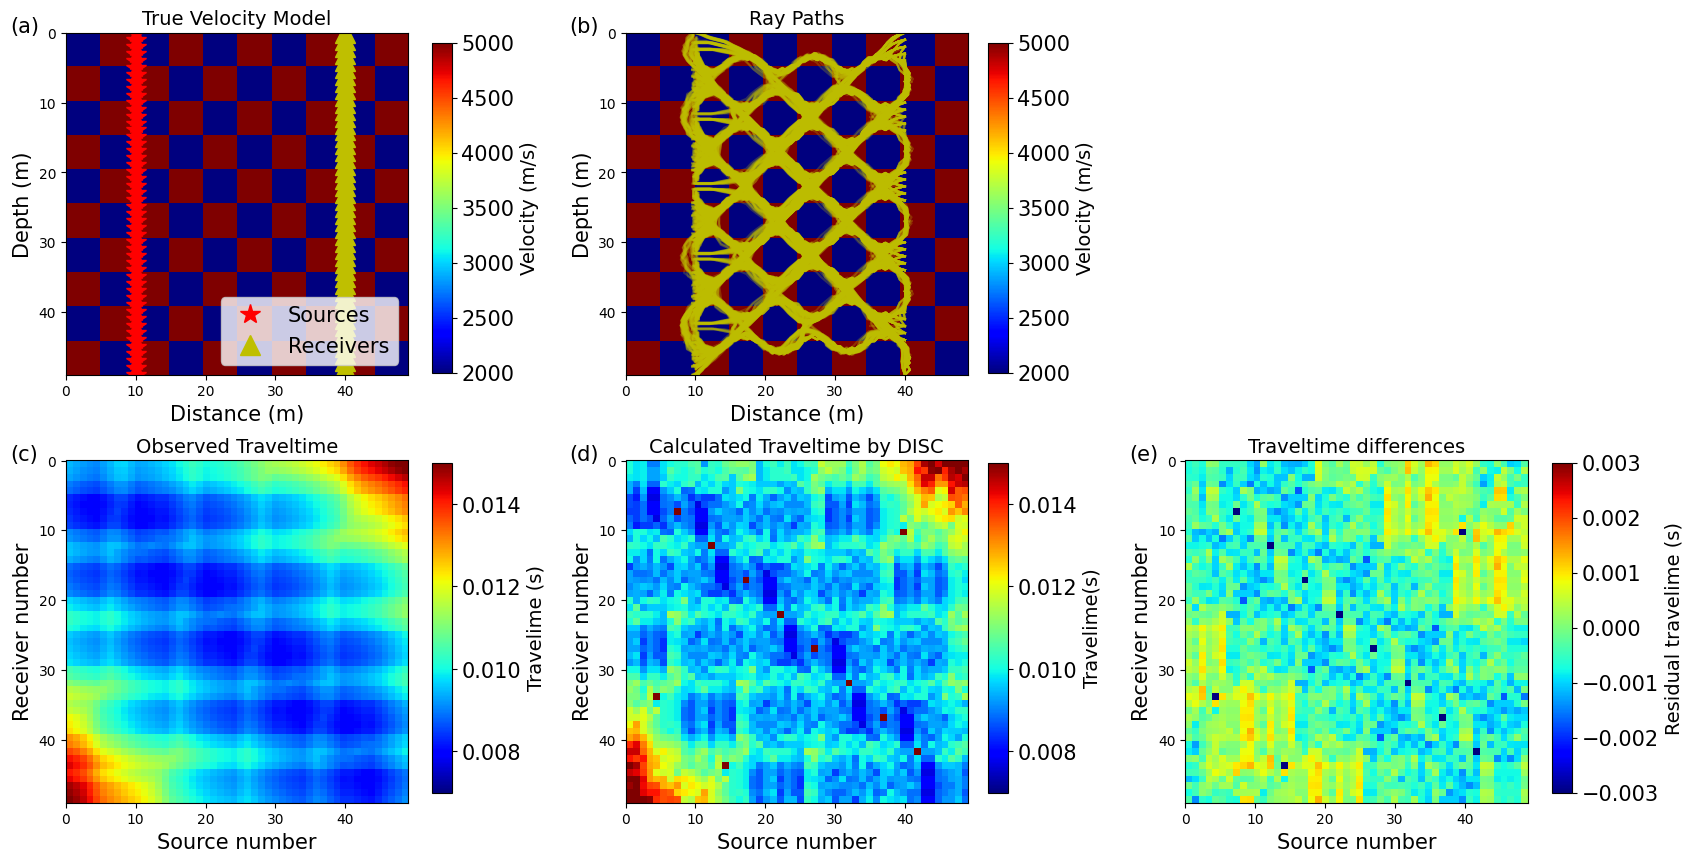

In [4]:
########Step 4 observed travel time comparison

time_eik=np.squeeze(traveltimes).reshape(n_sources,n_receivers)#traveltime estimated usig eikonal equation

time_cal=A.dot(1./v_true.reshape(nx*ny,1,order='C')).reshape(n_sources,n_receivers) #### traveltime calculated using ray path matrix and true velocity model

v_low = 2000
v_hig = 5000


print(time_eik.min(),time_eik.max())


tlow=0.007
thig=0.015

vasp=1

fig, axes = plt.subplots(2, 3, figsize=(20,10))
for ii,ax in enumerate(axes.flatten()):
	if ii==0:
		im1=ax.imshow(v_true,cmap='jet',vmin=v_low,vmax=v_hig,extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect=vasp)
		
		ax.set_ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
		ax.set_xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
		for label in ax.get_xticklabels() + ax.get_yticklabels():
				label.set_fontweight('normal')
				label.set_fontname('DejaVu Sans') 
		ax.text(-8,0, '(a)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
		colorbar_position = [0.33, 0.54, 0.01, 0.33]  # [left, bottom, width, height]
		cax = fig.add_axes(colorbar_position)
		cbar = fig.colorbar(im1, ax=axes[0], orientation='vertical', fraction=0.025, pad=0.03,cax=cax)
		cbar.set_label('Velocity (m/s)', fontsize=14, fontweight='normal', fontname='DejaVu Sans')
		cbar.ax.tick_params(labelsize=15)
		for label in cbar.ax.get_yticklabels():  # For horizontal: get_xticklabels()
			label.set_fontweight('normal')
			label.set_fontname('DejaVu Sans')
		ax.plot(sources_x,sources_y,'r*',  markersize=15)
		ax.plot(receivers_x,receivers_y,'y^',  markersize=15)
		ax.set_title('True Velocity Model', fontsize=14)
		ax.legend(['Sources','Receivers'],loc='lower right',prop={'family': 'DejaVu Sans', 'size': 15, 'weight': 'normal'})
			
	
		
	if ii==1:	
		im1=ax.imshow(v_true,cmap='jet',vmin=v_low,vmax=v_hig,extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect=vasp)
		ax.set_ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
		ax.set_xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
		for label in ax.get_xticklabels() + ax.get_yticklabels():
				label.set_fontweight('normal')
				label.set_fontname('DejaVu Sans') 
		ax.text(-8,0, '(b)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
		colorbar_position = [0.608, 0.54, 0.01, 0.33]  # [left, bottom, width, height]
		cax = fig.add_axes(colorbar_position)
		cbar = fig.colorbar(im1, ax=axes[0], orientation='vertical', fraction=0.025, pad=0.03,cax=cax)
		cbar.set_label('Velocity (m/s)', fontsize=14, fontweight='normal', fontname='DejaVu Sans')
		cbar.ax.tick_params(labelsize=15)
		for label in cbar.ax.get_yticklabels():  # For horizontal: get_xticklabels()
			label.set_fontweight('normal')
			label.set_fontname('DejaVu Sans')
		for ray_x, ray_y in ray_paths:
    			ax.plot(ray_x, ray_y, 'y-', alpha=0.25)
		ax.set_title('Ray Paths', fontsize=14)
		
	if ii==2:	
		ax.axis('off')
		
	if ii==3:	
		im1=ax.imshow(time_eik,cmap='jet',vmin=tlow,vmax=thig,extent=[0,(nx-1),(ny-1),0],aspect=vasp)
		
		ax.set_ylabel('Receiver number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
		ax.set_xlabel('Source number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
		for label in ax.get_xticklabels() + ax.get_yticklabels():
				label.set_fontweight('normal')
				label.set_fontname('DejaVu Sans') 
		ax.text(-8,0, '(c)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
		colorbar_position = [0.33, 0.12, 0.01, 0.33]  # [left, bottom, width, height]
		cax = fig.add_axes(colorbar_position)
		cbar = fig.colorbar(im1, ax=axes[0], orientation='vertical', fraction=0.025, pad=0.03,cax=cax)
		cbar.set_label('Travelime (s)', fontsize=14, fontweight='normal', fontname='DejaVu Sans')
		cbar.ax.tick_params(labelsize=15)
		for label in cbar.ax.get_yticklabels():  # For horizontal: get_xticklabels()
			label.set_fontweight('normal')
			label.set_fontname('DejaVu Sans')
		ax.set_title('Observed Traveltime', fontsize=14)
			
			
	if ii==4:	
		im1=ax.imshow(time_cal,cmap='jet',vmin=tlow,vmax=thig,extent=[0,(nx-1),(ny-1),0],aspect=vasp)
		
		ax.set_ylabel('Receiver number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
		ax.set_xlabel('Source number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')
		for label in ax.get_xticklabels() + ax.get_yticklabels():
				label.set_fontweight('normal')
				label.set_fontname('DejaVu Sans') 
		ax.text(-8,0, '(d)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
		colorbar_position = [0.608, 0.12, 0.01, 0.33]  # [left, bottom, width, height]
		cax = fig.add_axes(colorbar_position)
		cbar = fig.colorbar(im1, ax=axes[0], orientation='vertical', fraction=0.025, pad=0.03,cax=cax)
		cbar.set_label('Travelime(s)', fontsize=14, fontweight='normal', fontname='DejaVu Sans')
		cbar.ax.tick_params(labelsize=15)
		for label in cbar.ax.get_yticklabels():  # For horizontal: get_xticklabels()
			label.set_fontweight('normal')
			label.set_fontname('DejaVu Sans')
		ax.set_title('Calculated Traveltime by DISC', fontsize=14)
	if ii==5:	
		im1=ax.imshow(time_eik-time_cal,cmap='jet',vmin=-0.003,vmax=0.003,extent=[0,(nx-1),(ny-1),0],aspect=vasp)
		
		ax.set_ylabel('Receiver number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
		ax.set_xlabel('Source number', fontsize=15, fontweight='normal', fontname='DejaVu Sans')
		for label in ax.get_xticklabels() + ax.get_yticklabels():
				label.set_fontweight('normal')
				label.set_fontname('DejaVu Sans') 
		ax.text(-8,0, '(e)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal')
		colorbar_position = [0.89, 0.12, 0.01, 0.33]  # [left, bottom, width, height]
		cax = fig.add_axes(colorbar_position)
		cbar = fig.colorbar(im1, ax=axes[0], orientation='vertical', fraction=0.025, pad=0.03,cax=cax)
		cbar.set_label('Residual travelime (s)', fontsize=14, fontweight='normal', fontname='DejaVu Sans')
		cbar.ax.tick_params(labelsize=15)
		for label in cbar.ax.get_yticklabels():  # For horizontal: get_xticklabels()
			label.set_fontweight('normal')
			label.set_fontname('DejaVu Sans')
			label.set_fontsize(15)
		ax.set_title('Traveltime differences', fontsize=14)
		

plt.subplots_adjust(hspace=0.25)	
plt.subplots_adjust(wspace=0.3)	

plt.show()
	

In [5]:
########Step 5 tomography inversion using DISC method
oniter=15  ####number of outer iteration
initer=8  ####number of inner iteration

v_init=3500*np.ones_like(v_true) #####initialize starting model

v_disc=v_init

for i in range(oniter):
	_,ray_pathsini=compute_travel_times(v_disc, sources, receivers, dx, dy, nx, ny, 1)   ###ray traceing based on the given model
	opsr=build_ray_matrix(ray_pathsini, dx, dy, nx, ny)  ####build ray path matrix using the initial model

	nm=opsr.toarray().shape[1] 
	par_S={'nm':nm,'nd':nm,'nbox':[3,3,1],'ndat':[nx,ny,1],'ndim':3} ### shaping operator setting
	v_disc=tomoloop(v_disc,opsr,initer,nx,ny,nd,obst,par_S) ### gradient estimation and model update

	v_disc = np.clip(v_disc, v_low, v_high)
	
	print('iter=',i+1,msecal(obst,np.matmul(opsr.toarray(),1./v_disc.flatten(order='C'))))


iter= 1 4.562433174619393e-07
iter= 2 3.4627955173676065e-07
iter= 3 3.115542656557226e-07
iter= 4 2.878870903213612e-07
iter= 5 2.647226500337412e-07
iter= 6 2.367072750116699e-07
iter= 7 2.112327494663194e-07
iter= 8 1.98118484460185e-07
iter= 9 1.728814407016726e-07
iter= 10 1.6535043357016172e-07
iter= 11 1.5885845721330378e-07
iter= 12 1.589451640932081e-07
iter= 13 1.5033942893234965e-07
iter= 14 1.4309418751787813e-07
iter= 15 1.3595155249858476e-07


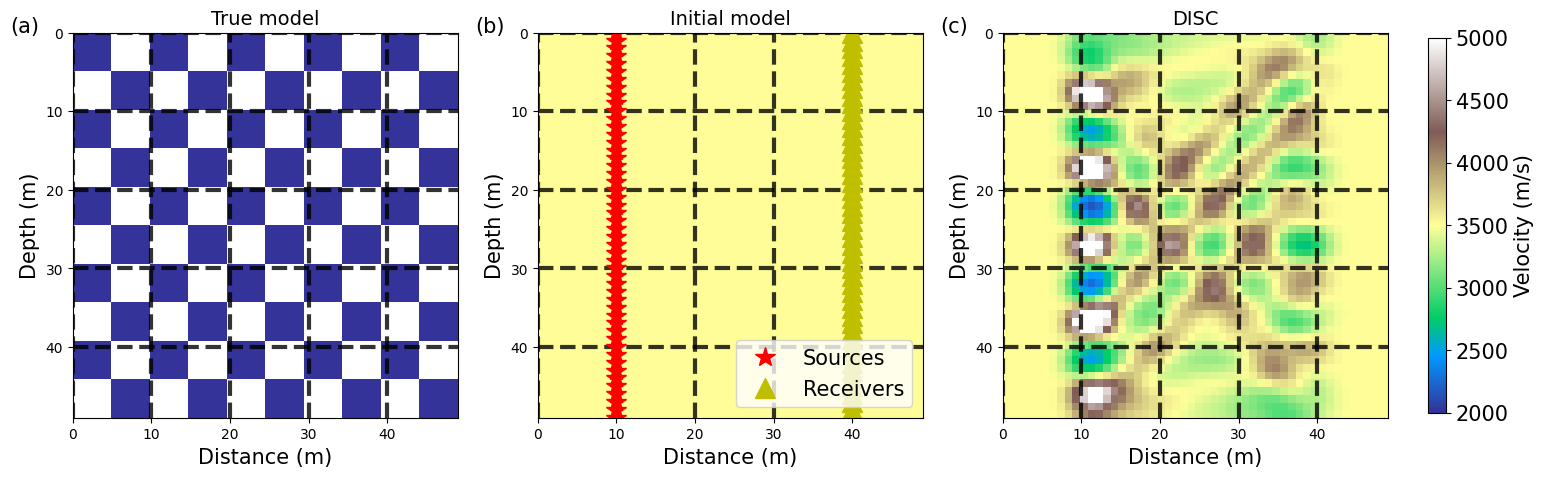

In [ ]:

figadd=address+'/Figure/'

####final result display

fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ii,ax in enumerate(axes.flatten()):
	if ii==0:
		im1=ax.imshow(v_true,cmap='terrain',vmin=v_low,vmax=v_hig,extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect=vasp)
		
		ax.set_ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
		ax.set_xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
		for label in ax.get_xticklabels() + ax.get_yticklabels():
				label.set_fontweight('normal')
				label.set_fontname('DejaVu Sans') 
		ax.text(-8,0, '(a)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
		ax.grid(True, which='both', linestyle='--', linewidth=3, alpha=0.8,color='black')
		colorbar_position = [0.9, 0.12, 0.01, 0.75]  # [left, bottom, width, height]
		cax = fig.add_axes(colorbar_position)
		cbar = fig.colorbar(im1, ax=axes[0], orientation='vertical', fraction=0.025, pad=0.03,cax=cax)
		cbar.set_label('Velocity (m/s)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')
		cbar.ax.tick_params(labelsize=15)
		for label in cbar.ax.get_yticklabels():  # For horizontal: get_xticklabels()
			label.set_fontweight('normal')
			label.set_fontname('DejaVu Sans')
		ax.set_title('True model', fontsize=14)
			
					
	if ii==1:	
		im1=ax.imshow(v_init,cmap='terrain',vmin=v_low,vmax=v_hig,extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect=vasp)
		ax.plot(sources_x,sources_y,'r*',  markersize=15)
		ax.plot(receivers_x,receivers_y,'y^',  markersize=15)

		ax.legend(['Sources','Receivers'],loc='lower right',prop={'family': 'DejaVu Sans', 'size': 15, 'weight': 'normal'})
		
		ax.set_ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
		ax.set_xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
		for label in ax.get_xticklabels() + ax.get_yticklabels():
				label.set_fontweight('normal')
				label.set_fontname('DejaVu Sans') 
		ax.text(-8,0, '(b)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
		ax.grid(True, which='both', linestyle='--', linewidth=3, alpha=0.8,color='black')
		ax.set_title('Initial model', fontsize=14)

		
	if ii==2:	
		im1=ax.imshow(v_disc,cmap='terrain',vmin=v_low,vmax=v_hig,extent=[0,(nx-1)*dx,(ny-1)*dy,0],aspect=vasp)
		
		ax.set_ylabel('Depth (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	
		ax.set_xlabel('Distance (m)', fontsize=15, fontweight='normal', fontname='DejaVu Sans')	 
		for label in ax.get_xticklabels() + ax.get_yticklabels():
				label.set_fontweight('normal')
				label.set_fontname('DejaVu Sans') 
		ax.text(-8,0, '(c)', fontsize = 15, fontname="DejaVu Sans",fontweight='normal') 
		ax.grid(True, which='both', linestyle='--', linewidth=3, alpha=0.8,color='black')
		ax.set_title('DISC', fontsize=14)
		
plt.subplots_adjust(hspace=0.25)	
plt.subplots_adjust(wspace=0.)	
# plt.savefig(figadd+"checkinv.png", dpi=300,bbox_inches='tight')	
plt.show()	